In [1]:
import pandas as pd
import sys
import numpy as np
from matplotlib import pyplot as plt

In [2]:
# make a list of file in the directory

import os

folder_of_interest_list = [
    'results_shipsnet_v02_00_SEU',
    'results_shipsnet_v02_01_SEU',
    'results_shipsnet_v02_02_SEU',
    'results_shipsnet_v02_03_SEU',
    ]

df_master = pd.read_csv(r'results_shipsnet_new_uniform\results_shipsnet_v02_00_SEU\_20250806_013752.csv')
# delete all rows leaving the columns only
# add a column called folder_name
df_master['folder_name'] = ""
df_master = df_master.drop(df_master.index)

for foil in folder_of_interest_list:

#folder_of_interest = 'results_shipsnet_01_SEU'
#folder_of_interest = 'results_GP_shipsnet_newslate_guide_SEU'

#df_master = pd.read_csv(r'results_4_variants\results_GP_shipsnet_newslate_guide_SEU\_20250718_234102.csv')
# add a column called timestamp, which is the filename without the extension
#df_master['timestamp'] = ""

    search_dir = os.path.join('results_shipsnet_new_uniform',
                            foil,
    )

    for file in os.listdir(search_dir):
        if file.endswith('.csv'):
            file_path = os.path.join(search_dir, file)
            print(f"Processing file: {file_path}")
            df = pd.read_csv(file_path)
            df['folder_name'] = foil
            # remove if accuracy_after_seu is nan
            df = df[df['accuracy_after_seu'].notna()]
            print(f"Number of rows after removing NaN in 'accuracy_after_seu': {len(df)}")
            #remove duplicate rows based on the first 10 columns
            print(f"Number of rows before dropping duplicates: {len(df)}")
            df = df.drop_duplicates(subset=df.columns[:10])
            print(f"Number of rows after dropping duplicates: {len(df)}")
            # append the data to the master dataframe
            df_master = pd.concat([df_master, df], ignore_index=True)
    #

# filter accuracy_change to only non nan values
#abs_acc_change_mean = df_master[df_master['accuracy_change'].notna()]['accuracy_change'].abs().mean()
#abs_acc_change_mean\
df_master['abs_acc_diff'] = df_master['accuracy_change'].abs()
df_master['log_mean_abs_difference'] = df_master['mean_abs_difference'].apply(lambda x: np.log10(x) if x > 0 else np.nan)
df_master['diff_per_softmax'] = df_master['abs_acc_diff'] / df_master['softmax_difference']

folder_name_map = {
    'results_shipsnet_v02_00_SEU': 'Model 0',
    'results_shipsnet_v02_01_SEU': 'Model 1',
    'results_shipsnet_v02_02_SEU': 'Model 2',
    'results_shipsnet_v02_03_SEU': 'Model 3',
}
df_master['folder_name'] = df_master['folder_name'].map(folder_name_map)
df_master['remarks'] = df_master['remarks'].fillna('No remarks')  # Fill NaN values in 'remarks' with empty strings

Processing file: results_shipsnet_new_uniform\results_shipsnet_v02_00_SEU\_20250806_013752.csv
Number of rows after removing NaN in 'accuracy_after_seu': 156
Number of rows before dropping duplicates: 156
Number of rows after dropping duplicates: 156
Processing file: results_shipsnet_new_uniform\results_shipsnet_v02_00_SEU\_20250806_014138.csv
Number of rows after removing NaN in 'accuracy_after_seu': 156
Number of rows before dropping duplicates: 156
Number of rows after dropping duplicates: 156
Processing file: results_shipsnet_new_uniform\results_shipsnet_v02_00_SEU\_20250806_014145.csv
Number of rows after removing NaN in 'accuracy_after_seu': 156
Number of rows before dropping duplicates: 156
Number of rows after dropping duplicates: 156
Processing file: results_shipsnet_new_uniform\results_shipsnet_v02_00_SEU\_20250806_022604.csv
Number of rows after removing NaN in 'accuracy_after_seu': 156
Number of rows before dropping duplicates: 156
Number of rows after dropping duplicates: 

In [3]:
def create_neat_latex(summary_table, comment="", highlight_method=None, ascending=True, highlight_cols=['abs_acc_diff', 'softmax_difference']):

    act_cols = highlight_cols
    
    df = summary_table.copy()

    # only keep act_cols that are actually present
    act_cols_all = ["abs_acc_diff","softmax_difference", "metrics_rms"]
    act_cols = [c for c in act_cols_all if c in df.columns]
    if not act_cols:
        raise ValueError("None of the expected act_cols are in the DataFrame.")

    def wrap_row(row, ascending=ascending):
        vals = [float(row[c]) for c in act_cols]
        target = (min if ascending else max)(vals)
        for c in act_cols:
            v = float(row[c])
            row[c] = r"\B{%d}{%0.4f}" % (1 if np.isclose(v, target) else 0, v)
        return row

    def wrap_col(col, ascending=ascending):
        # Only format columns we care about
        if col.name not in act_cols:
            return col
        numeric = col.astype(float)
        target = (numeric.min() if ascending else numeric.max())
        # write back by position to avoid label alignment issues
        for i in range(len(col)):
            v = float(numeric.iat[i])
            col.iat[i] = r"\B{%d}{%0.4f}" % (1 if np.isclose(v, target) else 0, v)
        return col

    # Use == for string comparison
    if highlight_method == "row":
        df = df.apply(wrap_row, axis=1)
    elif highlight_method == "col":
        df = df.apply(wrap_col, axis=0)
    elif highlight_method is None:
        pass


    # Format average
    #if "average" in df.columns:
    #    df["average"] = df["average"].map(lambda x: f"{float(x):.4f}")

    # Generate LaTeX without escaping macros
    latex_lines = df.to_latex(index=False, escape=False).splitlines()

    # Add macro definition
    #macro = r"\newcommand{\B}[2]{\ifnum#1=1 \textbf{#2}\else #2\fi}"
    centering = r"\centering"
    macro = r"\begin{table}[H]"
    final_lines = ["%"+comment, macro, centering]

    # Insert \midrule after every model_variant change
    header_done = False
    last_model = None
    for idx, line in enumerate(latex_lines):
        if not header_done:
            final_lines.append(line)
            if line.strip().endswith(r"\midrule"):
                header_done = True
            continue

        # Extract model name from start of line (split by &)
        model_name = line.strip().split("&")[0].strip()
        last_model = latex_lines[idx-1].strip().split("&")[0].strip() if idx > 0 else None
        
        #print("Model name:", model_name, "Last model:", last_model)
        if last_model is not None and model_name != last_model and not line.startswith(r"\bottomrule") and line.startswith(r"Model") and not last_model.startswith(r"\midrule"):
            final_lines.append(r"\midrule")
        if last_model == "Model 3" and model_name == "":
            final_lines.append(r"\midrule")
        final_lines.append(line)
        #last_model = model_name

    final_lines.append(r"\caption{...}")
    final_lines.append(r"\label{table:...}")
    final_lines.append(r"\end{table}")
    #print(final_lines)
    # Join into final LaTeX string
    latex_text = "\n".join(final_lines)
    latex_text = latex_text.replace('_', '\_')
    latex_text = latex_text.replace('llrllllllll', 'llrrrrrrrrr')
    latex_text = latex_text.replace('10.000000', '10')
    latex_text = latex_text.replace('1.000000', '1')
    latex_text = latex_text.replace('0.100000', '0.1')
    latex_text = latex_text.replace('model_variant', 'model\\_variant')
    latex_text = latex_text.replace('prior_b', 'prior\\_b')
    return (latex_text)

<>:83: SyntaxWarning: invalid escape sequence '\_'
<>:83: SyntaxWarning: invalid escape sequence '\_'
C:\Users\Revalda Putawara\AppData\Local\Temp\ipykernel_23820\566574963.py:83: SyntaxWarning: invalid escape sequence '\_'
  latex_text = latex_text.replace('_', '\_')


In [4]:
df_master

,activation_fn,prior,best_accuracy,prior_mu,prior_b,param_type,location_index,location_layer,location_module,bit_index,...,accuracy_after_seu,accuracy_change,softmax_difference,mean_abs_difference,remarks,original_bit_condition,folder_name,abs_acc_diff,log_mean_abs_difference,diff_per_softmax
0,relu,uniform,0.868437,0.0,1.0,lows,0,conv1,weight,0,...,0.91875,0.00500,0.060008,5.618616e-01,No remarks,1,Model 0,0.00500,-0.250371,0.083322
1,relu,uniform,0.868437,0.0,1.0,lows,0,conv1,weight,1,...,0.75125,-0.16250,0.927500,9.559580e+37,AutoUniform width adjusted;,0,Model 0,0.16250,37.980439,0.175202
2,relu,uniform,0.868437,0.0,1.0,widths,0,conv1,weight,1,...,0.75000,-0.16375,0.960000,2.162142e+38,No remarks,0,Model 0,0.16375,38.334884,0.170573
3,relu,uniform,0.868437,0.0,1.0,lows,0,conv1,weight,3,...,0.91250,-0.00125,0.044789,2.809308e-01,No remarks,1,Model 0,0.00125,-0.551401,0.027908
4,relu,uniform,0.868437,0.0,1.0,widths,0,conv1,weight,3,...,0.91500,0.00125,0.051512,6.353964e-01,AutoUniform width adjusted;,1,Model 0,0.00125,-0.196955,0.024266
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13099,actRWG,gaussian,0.694688,0.0,1.0,scales,-1,fc1,bias,10,...,0.75250,-0.00375,0.012344,1.250000e-01,No remarks,1,Model 3,0.00375,-0.903090,0.303801
13100,actRWG,gaussian,0.694688,0.0,1.0,locs,-1,fc1,bias,15,...,0.75625,0.00000,0.021826,6.103516e-05,No remarks,1,Model 3,0.00000,-4.214420,0.000000
13101,actRWG,gaussian,0.694688,0.0,1.0,scales,-1,fc1,bias,15,...,0.75625,0.00000,0.021858,3.906250e-03,No remarks,0,Model 3,0.00000,-2.408240,0.000000
13102,actRWG,gaussian,0.694688,0.0,1.0,locs,-1,fc1,bias,21,...,0.75750,0.00125,0.017474,9.536743e-07,No remarks,0,Model 3,0.00125,-6.020600,0.071534


In [5]:
df_master["bit_index"].unique()

array([ 0,  1,  3,  6, 10, 15, 21])

In [6]:
df_master[(df_master['bit_index'] == 1) & (df_master['prior'] == 'uniform')]

,activation_fn,prior,best_accuracy,prior_mu,prior_b,param_type,location_index,location_layer,location_module,bit_index,...,accuracy_after_seu,accuracy_change,softmax_difference,mean_abs_difference,remarks,original_bit_condition,folder_name,abs_acc_diff,log_mean_abs_difference,diff_per_softmax
1,relu,uniform,0.868437,0.0,1.0,lows,0,conv1,weight,1,...,0.75125,-0.16250,0.927500,9.559580e+37,AutoUniform width adjusted;,0,Model 0,0.16250,37.980439,0.175202
2,relu,uniform,0.868437,0.0,1.0,widths,0,conv1,weight,1,...,0.75000,-0.16375,0.960000,2.162142e+38,No remarks,0,Model 0,0.16375,38.334884,0.170573
14,relu,uniform,0.868437,0.0,1.0,lows,0,conv1,bias,1,...,0.91375,0.00000,0.053126,1.742523e+38,AutoUniform width adjusted;,0,Model 0,0.00000,38.241179,0.000000
15,relu,uniform,0.868437,0.0,1.0,widths,0,conv1,bias,1,...,0.75000,-0.16375,1.000000,1.665448e+38,No remarks,0,Model 0,0.16375,38.221531,0.163750
27,relu,uniform,0.868437,0.0,1.0,lows,0,conv2,weight,1,...,0.72625,-0.18750,0.943750,1.460014e+38,AutoUniform width adjusted;,0,Model 0,0.18750,38.164357,0.198675
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12131,actRWG,uniform,0.673750,0.0,1.0,widths,-1,conv2,bias,1,...,0.74500,0.00375,0.168404,2.728738e+38,No remarks,0,Model 3,0.00375,38.435962,0.022268
12143,actRWG,uniform,0.673750,0.0,1.0,lows,-1,fc1,weight,1,...,0.74625,0.00500,0.242817,7.601494e+37,AutoUniform width adjusted;,0,Model 3,0.00500,37.880899,0.020592
12144,actRWG,uniform,0.673750,0.0,1.0,widths,-1,fc1,weight,1,...,0.29500,-0.44625,0.685105,3.402823e+38,SEU went to NaN or Inf clipping to finite range;,0,Model 3,0.44625,38.531839,0.651360
12156,actRWG,uniform,0.673750,0.0,1.0,lows,-1,fc1,bias,1,...,0.75000,0.00875,1.000000,1.648301e+38,AutoUniform width adjusted;,0,Model 3,0.00875,38.217037,0.008750


In [7]:
df_master

,activation_fn,prior,best_accuracy,prior_mu,prior_b,param_type,location_index,location_layer,location_module,bit_index,...,accuracy_after_seu,accuracy_change,softmax_difference,mean_abs_difference,remarks,original_bit_condition,folder_name,abs_acc_diff,log_mean_abs_difference,diff_per_softmax
0,relu,uniform,0.868437,0.0,1.0,lows,0,conv1,weight,0,...,0.91875,0.00500,0.060008,5.618616e-01,No remarks,1,Model 0,0.00500,-0.250371,0.083322
1,relu,uniform,0.868437,0.0,1.0,lows,0,conv1,weight,1,...,0.75125,-0.16250,0.927500,9.559580e+37,AutoUniform width adjusted;,0,Model 0,0.16250,37.980439,0.175202
2,relu,uniform,0.868437,0.0,1.0,widths,0,conv1,weight,1,...,0.75000,-0.16375,0.960000,2.162142e+38,No remarks,0,Model 0,0.16375,38.334884,0.170573
3,relu,uniform,0.868437,0.0,1.0,lows,0,conv1,weight,3,...,0.91250,-0.00125,0.044789,2.809308e-01,No remarks,1,Model 0,0.00125,-0.551401,0.027908
4,relu,uniform,0.868437,0.0,1.0,widths,0,conv1,weight,3,...,0.91500,0.00125,0.051512,6.353964e-01,AutoUniform width adjusted;,1,Model 0,0.00125,-0.196955,0.024266
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13099,actRWG,gaussian,0.694688,0.0,1.0,scales,-1,fc1,bias,10,...,0.75250,-0.00375,0.012344,1.250000e-01,No remarks,1,Model 3,0.00375,-0.903090,0.303801
13100,actRWG,gaussian,0.694688,0.0,1.0,locs,-1,fc1,bias,15,...,0.75625,0.00000,0.021826,6.103516e-05,No remarks,1,Model 3,0.00000,-4.214420,0.000000
13101,actRWG,gaussian,0.694688,0.0,1.0,scales,-1,fc1,bias,15,...,0.75625,0.00000,0.021858,3.906250e-03,No remarks,0,Model 3,0.00000,-2.408240,0.000000
13102,actRWG,gaussian,0.694688,0.0,1.0,locs,-1,fc1,bias,21,...,0.75750,0.00125,0.017474,9.536743e-07,No remarks,0,Model 3,0.00125,-6.020600,0.071534


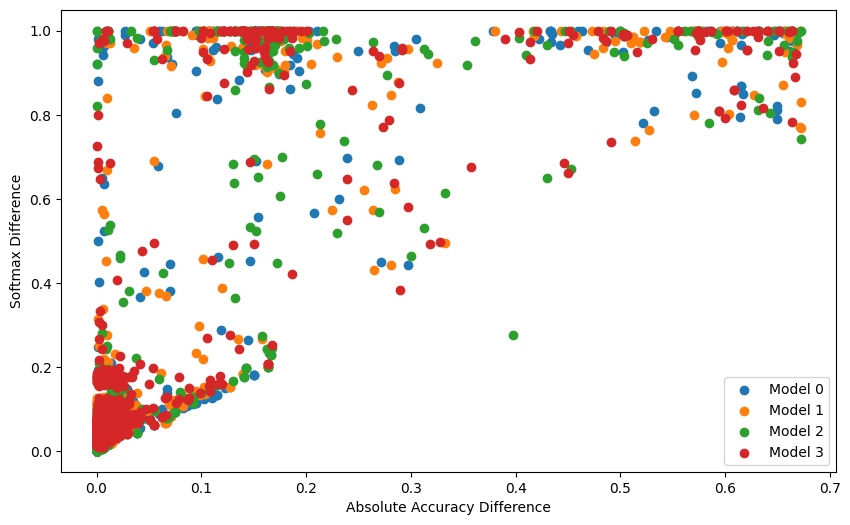

In [8]:
plt.figure(figsize=(10, 6))
for modelvariant in df_master['folder_name'].unique():
    subset = df_master[df_master['folder_name'] == modelvariant]
    plt.scatter(subset['abs_acc_diff'], subset['softmax_difference'], label=modelvariant)
#plt.scatter(df_master['abs_acc_diff'], df_master['softmax_difference'])
plt.xlabel('Absolute Accuracy Difference')
plt.ylabel('Softmax Difference')
#plt.title('Absolute Accuracy Difference vs Softmax Difference')
plt.legend()

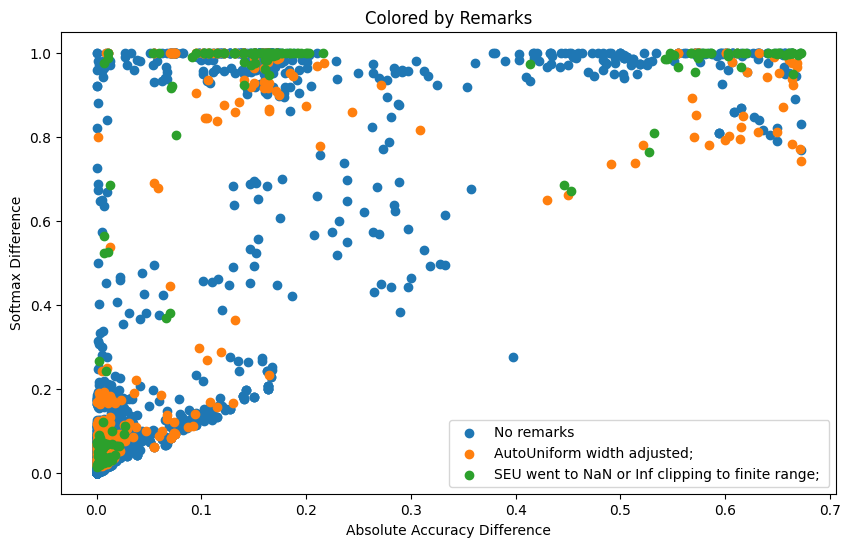

In [9]:
plt.figure(figsize=(10, 6))
for remarks in df_master['remarks'].unique():
    subset = df_master[df_master['remarks'] == remarks]
    plt.scatter(subset['abs_acc_diff'], subset['softmax_difference'], label=remarks)
#plt.scatter(df_master['abs_acc_diff'], df_master['softmax_difference'])
plt.xlabel('Absolute Accuracy Difference')
plt.ylabel('Softmax Difference')
plt.title('Colored by Remarks')
plt.legend()

In [10]:
df_summary = df_master.groupby(['activation_fn',
                   'prior',
                   'param_type',
                   'location_index',
                   'location_layer',
                   'location_module',
                   'folder_name'])[["abs_acc_diff","softmax_difference"]].mean().reset_index()
df_summary

,activation_fn,prior,param_type,location_index,location_layer,location_module,folder_name,abs_acc_diff,softmax_difference
0,actRWG,gaussian,locs,-1,conv1,bias,Model 0,0.005714,0.016665
1,actRWG,gaussian,locs,-1,conv1,bias,Model 1,0.003929,0.024045
2,actRWG,gaussian,locs,-1,conv1,bias,Model 2,0.003036,0.011110
3,actRWG,gaussian,locs,-1,conv1,bias,Model 3,0.001786,0.019138
4,actRWG,gaussian,locs,-1,conv1,weight,Model 0,0.003393,0.013902
...,...,...,...,...,...,...,...,...,...
2011,tanh,uniform,widths,0,fc1,bias,Model 3,0.031458,0.226284
2012,tanh,uniform,widths,0,fc1,weight,Model 0,0.029792,0.204715
2013,tanh,uniform,widths,0,fc1,weight,Model 1,0.033125,0.217031
2014,tanh,uniform,widths,0,fc1,weight,Model 2,0.027708,0.211646


In [11]:
#df_master[df_master['bit_index']==1].to_csv("index_1_check.csv", index=False)

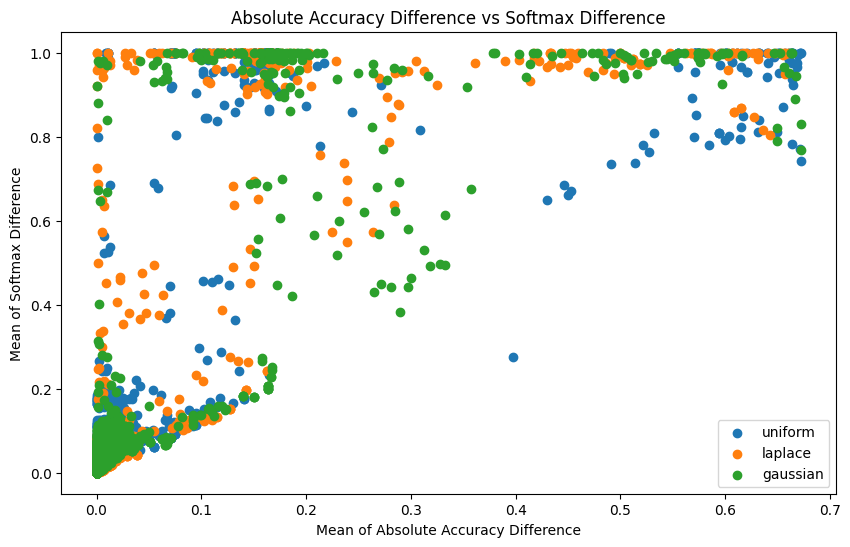

In [12]:
# make a scatter plot of abs_acc_diff vs softmax_difference
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
for prior in df_master['prior'].unique():
    subset = df_master[df_master['prior'] == prior]
    plt.scatter(subset['abs_acc_diff'], subset['softmax_difference'], label=prior)
plt.xlabel('Mean of Absolute Accuracy Difference')
plt.ylabel('Mean of Softmax Difference')
plt.title('Absolute Accuracy Difference vs Softmax Difference')
plt.legend()
plt.show()

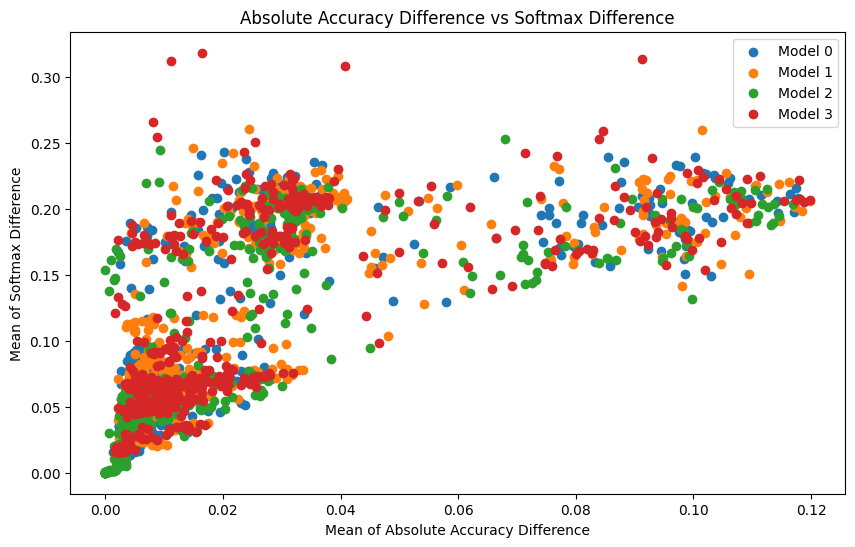

In [13]:
# make a scatter plot of abs_acc_diff vs softmax_difference
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
for folder in df_summary['folder_name'].unique():
    subset = df_summary[df_summary['folder_name'] == folder]
    plt.scatter(subset['abs_acc_diff'], subset['softmax_difference'], label=folder)
plt.xlabel('Mean of Absolute Accuracy Difference')
plt.ylabel('Mean of Softmax Difference')
plt.title('Absolute Accuracy Difference vs Softmax Difference')
plt.legend()
plt.show()

In [14]:
df_summary_2 = df_master.groupby(['location_layer',
                                  'location_module'])[["abs_acc_diff","softmax_difference"]].mean().reset_index()
#df_summary_2['diff_per_softmax'] = df_summary_2['abs_acc_diff'] / df_summary_2['softmax_difference']
# create a metric called metrics_rms which is the quare toot of abs_acc_diff squared added with softmax_difference squared
df_summary_2['metrics_rms'] = np.sqrt((df_summary_2['abs_acc_diff']**2 + df_summary_2['softmax_difference']**2)/2)
df_summary_2

,location_layer,location_module,abs_acc_diff,softmax_difference,metrics_rms
0,conv1,bias,0.009481,0.064144,0.045850
1,conv1,weight,0.012944,0.076155,0.054622
2,conv2,bias,0.008851,0.072327,0.051525
3,conv2,weight,0.013596,0.098658,0.070421
4,fc1,bias,0.045896,0.171973,0.125860
5,fc1,weight,0.055494,0.161131,0.120504


In [15]:
latex_text = create_neat_latex(df_summary_2, 
                               comment="Summary of absolute accuracy difference and softmax difference by layer and module for Deterministic CNN",
                               highlight_cols = ['abs_acc_diff', 'softmax_difference', 'metrics_rms'],
                               ascending=True,
                               highlight_method="col")
print(latex_text)

C:\Users\Revalda Putawara\AppData\Local\Temp\ipykernel_23820\566574963.py:30: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '\B{0}{0.0095}' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  col.iat[i] = r"\B{%d}{%0.4f}" % (1 if np.isclose(v, target) else 0, v)
C:\Users\Revalda Putawara\AppData\Local\Temp\ipykernel_23820\566574963.py:30: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '\B{1}{0.0641}' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  col.iat[i] = r"\B{%d}{%0.4f}" % (1 if np.isclose(v, target) else 0, v)
C:\Users\Revalda Putawara\AppData\Local\Temp\ipykernel_23820\566574963.py:30: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '\B{1}{0.0458}' has dtype 

%Summary of absolute accuracy difference and softmax difference by layer and module for Deterministic CNN
\begin{table}[H]
\centering
\begin{tabular}{lllll}
\toprule
location\_layer & location\_module & abs\_acc\_diff & softmax\_difference & metrics\_rms \\
\midrule
conv1 & bias & \B{0}{0.0095} & \B{1}{0.0641} & \B{1}{0.0458} \\
conv1 & weight & \B{0}{0.0129} & \B{0}{0.0762} & \B{0}{0.0546} \\
conv2 & bias & \B{1}{0.0089} & \B{0}{0.0723} & \B{0}{0.0515} \\
conv2 & weight & \B{0}{0.0136} & \B{0}{0.0987} & \B{0}{0.0704} \\
fc1 & bias & \B{0}{0.0459} & \B{0}{0.1720} & \B{0}{0.1259} \\
fc1 & weight & \B{0}{0.0555} & \B{0}{0.1611} & \B{0}{0.1205} \\
\bottomrule
\end{tabular}
\caption{...}
\label{table:...}
\end{table}


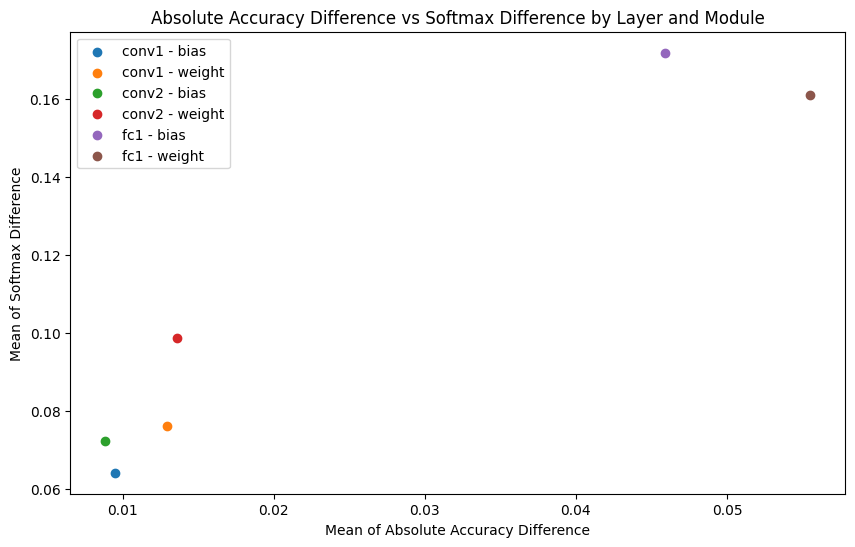

In [16]:
# make a scatter plot of abs_acc_diff vs softmax_difference
# create different shape by location_layer and location_module
plt.figure(figsize=(10, 6))
for layer in df_summary_2['location_layer'].unique():
    for module in df_summary_2['location_module'].unique():
        subset = df_summary_2[(df_summary_2['location_layer'] == layer) & (df_summary_2['location_module'] == module)]
        plt.scatter(subset['abs_acc_diff'], subset['softmax_difference'], label=f'{layer} - {module}')
plt.xlabel('Mean of Absolute Accuracy Difference')
plt.ylabel('Mean of Softmax Difference')
plt.title('Absolute Accuracy Difference vs Softmax Difference by Layer and Module')
plt.legend()

In [17]:
df_summary_3 = df_master.groupby(['activation_fn'])[["abs_acc_diff","softmax_difference"]].mean().reset_index()
#df_summary_3['diff_per_softmax'] = df_summary_3['abs_acc_diff'] / df_summary_3['softmax_difference']
df_summary_3['metrics_rms'] = np.sqrt((df_summary_3['abs_acc_diff']**2 + df_summary_3['softmax_difference']**2)/2)
df_summary_3

latex_text = create_neat_latex(df_summary_3, 
                               comment="Summary of absolute accuracy difference and softmax difference by activation function for Bayesian CNN",
                               highlight_cols = ['abs_acc_diff', 'softmax_difference', 'metrics_rms'],
                               ascending=True,
                               highlight_method="col")
print(latex_text)

%Summary of absolute accuracy difference and softmax difference by activation function for Bayesian CNN
\begin{table}[H]
\centering
\begin{tabular}{llll}
\toprule
activation\_fn & abs\_acc\_diff & softmax\_difference & metrics\_rms \\
\midrule
actRWG & \B{1}{0.0168} & \B{0}{0.0958} & \B{0}{0.0688} \\
actWG & \B{0}{0.0213} & \B{0}{0.0964} & \B{0}{0.0698} \\
relu & \B{0}{0.0379} & \B{0}{0.1626} & \B{0}{0.1180} \\
relu6 & \B{0}{0.0248} & \B{0}{0.1012} & \B{0}{0.0737} \\
sigmoid & \B{0}{0.0190} & \B{1}{0.0800} & \B{1}{0.0581} \\
sin & \B{0}{0.0294} & \B{0}{0.1056} & \B{0}{0.0775} \\
tanh & \B{0}{0.0214} & \B{0}{0.1102} & \B{0}{0.0794} \\
\bottomrule
\end{tabular}
\caption{...}
\label{table:...}
\end{table}


C:\Users\Revalda Putawara\AppData\Local\Temp\ipykernel_23820\566574963.py:30: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '\B{1}{0.0168}' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  col.iat[i] = r"\B{%d}{%0.4f}" % (1 if np.isclose(v, target) else 0, v)
C:\Users\Revalda Putawara\AppData\Local\Temp\ipykernel_23820\566574963.py:30: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '\B{0}{0.0958}' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  col.iat[i] = r"\B{%d}{%0.4f}" % (1 if np.isclose(v, target) else 0, v)
C:\Users\Revalda Putawara\AppData\Local\Temp\ipykernel_23820\566574963.py:30: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '\B{0}{0.0688}' has dtype 

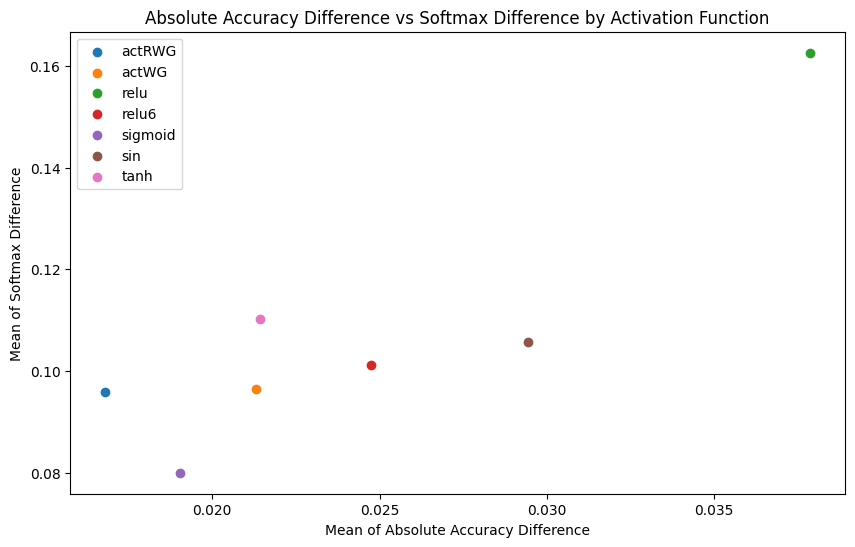

In [18]:
# make a scatter plot of abs_acc_diff vs softmax_difference
plt.figure(figsize=(10, 6))
for activation in df_summary_3['activation_fn'].unique():
    subset = df_summary_3[df_summary_3['activation_fn'] == activation]
    plt.scatter(subset['abs_acc_diff'], subset['softmax_difference'], label=activation)
plt.xlabel('Mean of Absolute Accuracy Difference')
plt.ylabel('Mean of Softmax Difference')
plt.title('Absolute Accuracy Difference vs Softmax Difference by Activation Function')
plt.legend()

In [19]:
df_summary_4 = df_master.groupby(['prior'])[["abs_acc_diff","softmax_difference"]].mean().reset_index()
df_summary_4['metrics_rms'] = np.sqrt((df_summary_4['abs_acc_diff']**2 + df_summary_4['softmax_difference']**2)/2)
df_summary_4

,prior,abs_acc_diff,softmax_difference,metrics_rms
0,gaussian,0.023051,0.101866,0.073851
1,laplace,0.023613,0.104637,0.075850
2,uniform,0.026467,0.115691,0.083919


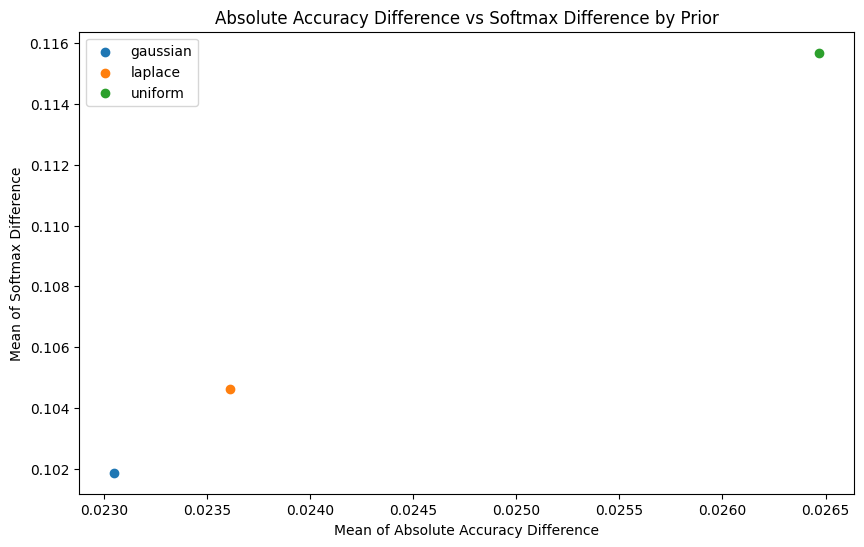

In [20]:
# make a scatter plot of abs_acc_diff vs softmax_difference
plt.figure(figsize=(10, 6))
for prior in df_summary_4['prior'].unique():
    subset = df_summary_4[df_summary_4['prior'] == prior]
    plt.scatter(subset['abs_acc_diff'], subset['softmax_difference'], label=prior)
plt.xlabel('Mean of Absolute Accuracy Difference')
plt.ylabel('Mean of Softmax Difference')
plt.title('Absolute Accuracy Difference vs Softmax Difference by Prior')
plt.legend()
plt.show()

In [21]:
df_summary_5 = df_master.groupby(['prior','param_type'])[["abs_acc_diff","softmax_difference"]].mean().reset_index()
#df_summary_5['diff_per_softmax'] = df_summary_5['abs_acc_diff'] / df_summary_5['softmax_difference']
df_summary_5['metrics_rms'] = np.sqrt((df_summary_5['abs_acc_diff']**2 + df_summary_5['softmax_difference']**2)/2)
df_summary_5

latex_text = create_neat_latex(df_summary_5, 
                               comment="Summary of absolute accuracy difference and softmax difference by prior and its parameter for Bayesian CNN",
                               highlight_cols = ['abs_acc_diff', 'softmax_difference', 'metrics_rms'],
                               ascending=True,
                               highlight_method="col")
print(latex_text)

%Summary of absolute accuracy difference and softmax difference by prior and its parameter for Bayesian CNN
\begin{table}[H]
\centering
\begin{tabular}{lllll}
\toprule
prior & param\_type & abs\_acc\_diff & softmax\_difference & metrics\_rms \\
\midrule
gaussian & locs & \B{1}{0.0177} & \B{1}{0.0794} & \B{1}{0.0575} \\
gaussian & scales & \B{0}{0.0293} & \B{0}{0.1281} & \B{0}{0.0929} \\
laplace & locs & \B{0}{0.0193} & \B{0}{0.0823} & \B{0}{0.0598} \\
laplace & scales & \B{0}{0.0287} & \B{0}{0.1306} & \B{0}{0.0946} \\
uniform & lows & \B{0}{0.0231} & \B{0}{0.1054} & \B{0}{0.0763} \\
uniform & widths & \B{0}{0.0303} & \B{0}{0.1277} & \B{0}{0.0928} \\
\bottomrule
\end{tabular}
\caption{...}
\label{table:...}
\end{table}


C:\Users\Revalda Putawara\AppData\Local\Temp\ipykernel_23820\566574963.py:30: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '\B{1}{0.0177}' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  col.iat[i] = r"\B{%d}{%0.4f}" % (1 if np.isclose(v, target) else 0, v)
C:\Users\Revalda Putawara\AppData\Local\Temp\ipykernel_23820\566574963.py:30: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '\B{1}{0.0794}' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  col.iat[i] = r"\B{%d}{%0.4f}" % (1 if np.isclose(v, target) else 0, v)
C:\Users\Revalda Putawara\AppData\Local\Temp\ipykernel_23820\566574963.py:30: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '\B{1}{0.0575}' has dtype 

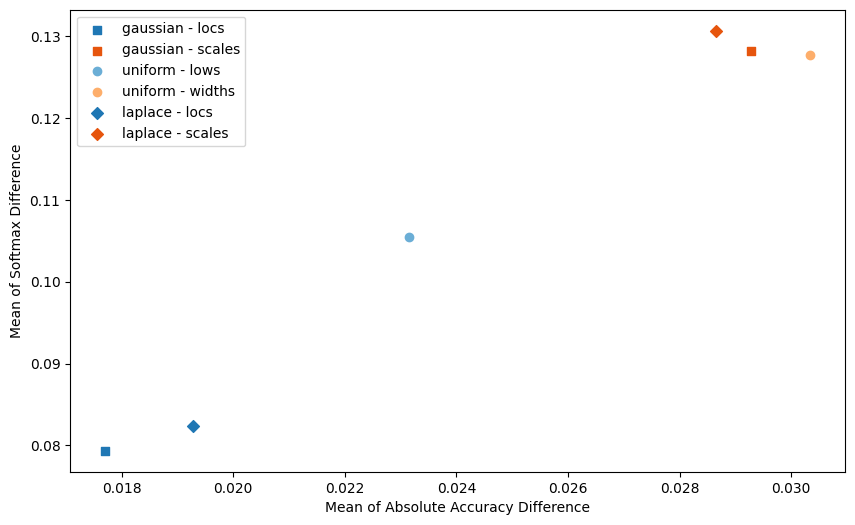

In [22]:
# make a scatter plot of abs_acc_diff vs softmax_difference
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# make a custom cumbination of prior and param_type
param_dict = {
    'gaussian': ['locs','scales'],
    'uniform': ['lows','widths'],
    'laplace': ['locs','scales'],}


prior_markers = {
    'gaussian': 's',
    'uniform': 'o',
    'laplace' : 'D', # 
}

param_colors = {
    'locs': '#1f77b4',
    'lows': '#6baed6',
    'scales':'#e6550d',
    'widths': '#fdae6b',
}

for prior in param_dict.keys():
    for param_type in param_dict[prior]:
        subset = df_summary_5[(df_summary_5['prior'] == prior) & (df_summary_5['param_type'] == param_type)]
        plt.scatter(subset['abs_acc_diff'], subset['softmax_difference'], label=f'{prior} - {param_type}', marker=prior_markers[prior], color=param_colors[param_type])
plt.xlabel('Mean of Absolute Accuracy Difference')
plt.ylabel('Mean of Softmax Difference')
#plt.title('Absolute Accuracy Difference vs Softmax Difference by Layer and Module')
plt.legend()
plt.show()

# giva a very contrast different color other that seaborn-darkgrid

#plt.style.use('seaborn-darkgrid')

#for prior in param_dict.keys():
#    for param_type in param_dict[prior]:
#        subset = df_summary_5[(df_summary_5['prior'] == prior) & (df_summary_5['param_type'] == param_type)]
#        plt.scatter(subset['abs_acc_diff'], subset['softmax_difference'], label=f'{prior} - {param_type}')


#plt.xlabel('Mean of Absolute Accuracy Difference')
#plt.ylabel('Mean of Softmax Difference')
#plt.title('Absolute Accuracy Difference vs Softmax Difference by Prior and Parameter Type')
#plt.legend()
#plt.show()

In [23]:
df_summary_6 = df_master.groupby(['folder_name'])[["abs_acc_diff","softmax_difference"]].mean().reset_index()
#df_summary_6['diff_per_softmax'] = df_summary_6['abs_acc_diff'] / df_summary_6['softmax_difference']
df_summary_6['metrics_rms'] = np.sqrt((df_summary_6['abs_acc_diff']**2 + df_summary_6['softmax_difference']**2)/2)
df_summary_6

,folder_name,abs_acc_diff,softmax_difference,metrics_rms
0,Model 0,0.024265,0.110569,0.080045
1,Model 1,0.025410,0.110913,0.080459
2,Model 2,0.022094,0.094354,0.068523
3,Model 3,0.025739,0.113756,0.082471


In [24]:
latex_text = create_neat_latex(df_summary_6, 
                               comment="Summary of absolute accuracy difference and softmax difference by model variant for Bayesian CNN",
                               highlight_cols = ['abs_acc_diff', 'softmax_difference', 'metrics_rms'],
                               ascending=True,
                               highlight_method="col")
print(latex_text)

%Summary of absolute accuracy difference and softmax difference by model variant for Bayesian CNN
\begin{table}[H]
\centering
\begin{tabular}{llll}
\toprule
folder\_name & abs\_acc\_diff & softmax\_difference & metrics\_rms \\
\midrule
Model 0 & \B{0}{0.0243} & \B{0}{0.1106} & \B{0}{0.0800} \\
\midrule
Model 1 & \B{0}{0.0254} & \B{0}{0.1109} & \B{0}{0.0805} \\
\midrule
Model 2 & \B{1}{0.0221} & \B{1}{0.0944} & \B{1}{0.0685} \\
\midrule
Model 3 & \B{0}{0.0257} & \B{0}{0.1138} & \B{0}{0.0825} \\
\bottomrule
\end{tabular}
\caption{...}
\label{table:...}
\end{table}


C:\Users\Revalda Putawara\AppData\Local\Temp\ipykernel_23820\566574963.py:30: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '\B{0}{0.0243}' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  col.iat[i] = r"\B{%d}{%0.4f}" % (1 if np.isclose(v, target) else 0, v)
C:\Users\Revalda Putawara\AppData\Local\Temp\ipykernel_23820\566574963.py:30: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '\B{0}{0.1106}' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  col.iat[i] = r"\B{%d}{%0.4f}" % (1 if np.isclose(v, target) else 0, v)
C:\Users\Revalda Putawara\AppData\Local\Temp\ipykernel_23820\566574963.py:30: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '\B{0}{0.0800}' has dtype 

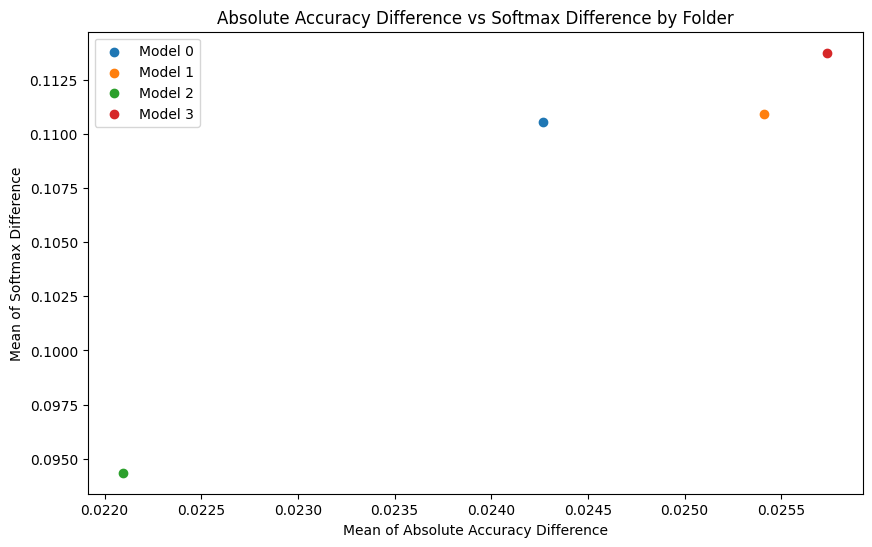

In [25]:
# make a scatter plot of abs_acc_diff vs softmax_difference from df_summary_6
plt.figure(figsize=(10, 6))
for folder in df_summary_6['folder_name'].unique():
    subset = df_summary_6[df_summary_6['folder_name'] == folder]
    plt.scatter(subset['abs_acc_diff'], subset['softmax_difference'], label=folder)
plt.xlabel('Mean of Absolute Accuracy Difference')
plt.ylabel('Mean of Softmax Difference')
plt.title('Absolute Accuracy Difference vs Softmax Difference by Folder')
plt.legend()
plt.show()


In [26]:
df_summary_7 = df_master.groupby(['location_index','location_layer', 'location_module'])[["abs_acc_diff","softmax_difference"]].mean().reset_index()
df_summary_7['metrics_rms'] = np.sqrt((df_summary_7['abs_acc_diff']**2 + df_summary_7['softmax_difference']**2)/2)
df_summary_7

,location_index,location_layer,location_module,abs_acc_diff,softmax_difference,metrics_rms
0,-1,conv1,bias,0.009441,0.064039,0.045772
1,-1,conv1,weight,0.012905,0.075938,0.054466
2,-1,conv2,bias,0.008909,0.072701,0.051792
3,-1,conv2,weight,0.012888,0.085494,0.061137
4,-1,fc1,bias,0.058285,0.175765,0.130940
5,-1,fc1,weight,0.063230,0.159858,0.121558
6,0,conv1,bias,0.009522,0.064249,0.045927
7,0,conv1,weight,0.012983,0.076372,0.054778
8,0,conv2,bias,0.008793,0.071954,0.051258
9,0,conv2,weight,0.014304,0.111821,0.079714


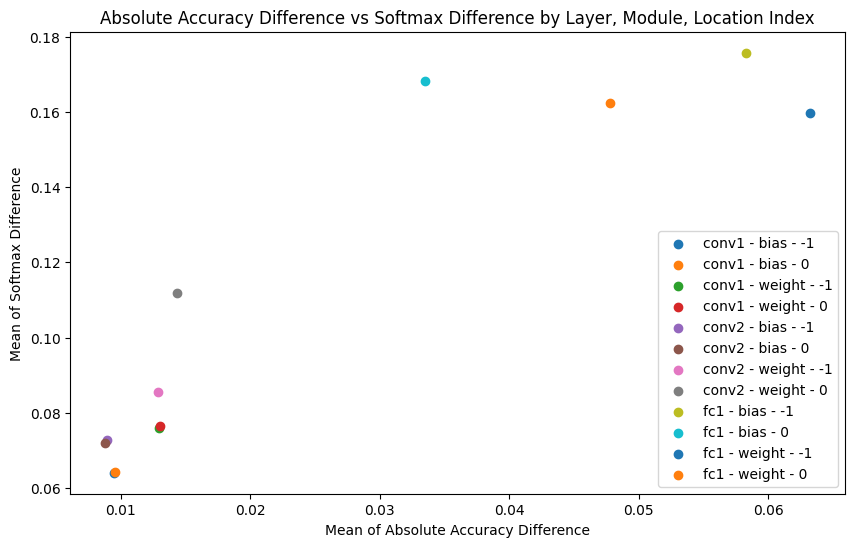

In [27]:
plt.figure(figsize=(10, 6))
for layer in df_summary_7['location_layer'].unique():
    for module in df_summary_7['location_module'].unique():
        for location_index in df_summary_7['location_index'].unique():
            subset = df_summary_7[(df_summary_7['location_layer'] == layer) & (df_summary_7['location_module'] == module) & (df_summary_7['location_index'] == location_index)]
            plt.scatter(subset['abs_acc_diff'], subset['softmax_difference'],label=f'{layer} - {module} - {location_index}')
plt.xlabel('Mean of Absolute Accuracy Difference')
plt.ylabel('Mean of Softmax Difference')
plt.title('Absolute Accuracy Difference vs Softmax Difference by Layer, Module, Location Index')
plt.legend()
plt.show()

In [28]:
df_summary_8 = df_master.groupby(['original_bit_condition'])[["abs_acc_diff","softmax_difference"]].mean().reset_index()
#df_summary_8['diff_per_softmax'] = df_summary_8['abs_acc_diff'] / df_summary_8['softmax_difference']
df_summary_8['metrics_rms'] = np.sqrt((df_summary_8['abs_acc_diff']**2 + df_summary_8['softmax_difference']**2)/2)
df_summary_8

# robust machine learning systems pdf
# the bit-flips from 1 to 0 have a more drastic effect on the system’s classification accuracy than bit-flips from 0 to 1 [132]
# my result shows that bit-flips from 0 to 1 have a more drastic effect

,original_bit_condition,abs_acc_diff,softmax_difference,metrics_rms
0,0,0.045532,0.173440,0.126796
1,1,0.006934,0.052942,0.037756


In [29]:
latex_text = create_neat_latex(df_summary_8, 
                               comment="Summary of absolute accuracy difference and softmax difference by original bit condition for Bayesian CNN",
                               highlight_cols = ['abs_acc_diff', 'softmax_difference', 'metrics_rms'],
                               ascending=True,
                               highlight_method="col")
print(latex_text)

%Summary of absolute accuracy difference and softmax difference by original bit condition for Bayesian CNN
\begin{table}[H]
\centering
\begin{tabular}{rlll}
\toprule
original\_bit\_condition & abs\_acc\_diff & softmax\_difference & metrics\_rms \\
\midrule
0 & \B{0}{0.0455} & \B{0}{0.1734} & \B{0}{0.1268} \\
1 & \B{1}{0.0069} & \B{1}{0.0529} & \B{1}{0.0378} \\
\bottomrule
\end{tabular}
\caption{...}
\label{table:...}
\end{table}


C:\Users\Revalda Putawara\AppData\Local\Temp\ipykernel_23820\566574963.py:30: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '\B{0}{0.0455}' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  col.iat[i] = r"\B{%d}{%0.4f}" % (1 if np.isclose(v, target) else 0, v)
C:\Users\Revalda Putawara\AppData\Local\Temp\ipykernel_23820\566574963.py:30: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '\B{0}{0.1734}' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  col.iat[i] = r"\B{%d}{%0.4f}" % (1 if np.isclose(v, target) else 0, v)
C:\Users\Revalda Putawara\AppData\Local\Temp\ipykernel_23820\566574963.py:30: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '\B{0}{0.1268}' has dtype 

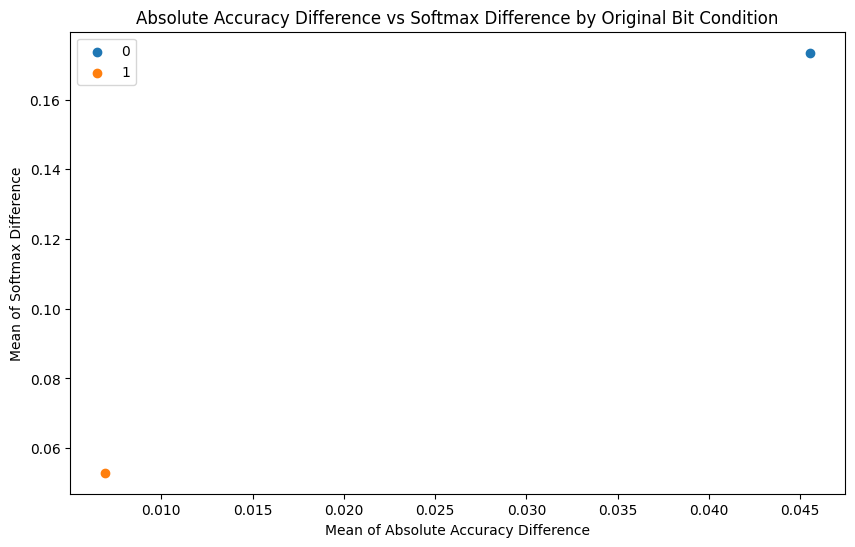

In [30]:
plt.figure(figsize=(10, 6))
for orbitloc in df_summary_8['original_bit_condition'].unique():
    subset = df_summary_8[(df_summary_8['original_bit_condition']==orbitloc)]
    plt.scatter(subset['abs_acc_diff'], subset['softmax_difference'],label=f'{orbitloc}')
plt.xlabel('Mean of Absolute Accuracy Difference')
plt.ylabel('Mean of Softmax Difference')
plt.title('Absolute Accuracy Difference vs Softmax Difference by Original Bit Condition')
plt.legend()
plt.show()

In [31]:
df_summary_9 = df_master.groupby(['bit_index'])[["abs_acc_diff","softmax_difference"]].mean().reset_index()
#df_summary_9['diff_per_softmax'] = df_summary_9['abs_acc_diff'] / df_summary_9['softmax_difference']
df_summary_9['metrics_rms'] = np.sqrt((df_summary_9['abs_acc_diff']**2 + df_summary_9['softmax_difference']**2)/2)
df_summary_9

,bit_index,abs_acc_diff,softmax_difference,metrics_rms
0,0,0.007458,0.053293,0.038051
1,1,0.120603,0.408042,0.300868
2,3,0.007038,0.052738,0.037622
3,6,0.006987,0.052928,0.037751
4,10,0.006729,0.052472,0.037407
5,15,0.006673,0.052493,0.037417
6,21,0.006692,0.052766,0.037610


In [32]:
latex_text = create_neat_latex(df_summary_9, 
                               comment="Summary of absolute accuracy difference and softmax difference by bit location for Deterministic CNN",
                               highlight_cols = ['abs_acc_diff', 'softmax_difference', 'metrics_rms'],
                               ascending=True,
                               highlight_method="col")
print(latex_text)

%Summary of absolute accuracy difference and softmax difference by bit location for Deterministic CNN
\begin{table}[H]
\centering
\begin{tabular}{rlll}
\toprule
bit\_index & abs\_acc\_diff & softmax\_difference & metrics\_rms \\
\midrule
0 & \B{0}{0.0075} & \B{0}{0.0533} & \B{0}{0.0381} \\
1 & \B{0}{0.1206} & \B{0}{0.4080} & \B{0}{0.3009} \\
3 & \B{0}{0.0070} & \B{0}{0.0527} & \B{0}{0.0376} \\
6 & \B{0}{0.0070} & \B{0}{0.0529} & \B{0}{0.0378} \\
10 & \B{0}{0.0067} & \B{1}{0.0525} & \B{1}{0.0374} \\
15 & \B{1}{0.0067} & \B{0}{0.0525} & \B{0}{0.0374} \\
21 & \B{0}{0.0067} & \B{0}{0.0528} & \B{0}{0.0376} \\
\bottomrule
\end{tabular}
\caption{...}
\label{table:...}
\end{table}


C:\Users\Revalda Putawara\AppData\Local\Temp\ipykernel_23820\566574963.py:30: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '\B{0}{0.0075}' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  col.iat[i] = r"\B{%d}{%0.4f}" % (1 if np.isclose(v, target) else 0, v)
C:\Users\Revalda Putawara\AppData\Local\Temp\ipykernel_23820\566574963.py:30: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '\B{0}{0.0533}' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  col.iat[i] = r"\B{%d}{%0.4f}" % (1 if np.isclose(v, target) else 0, v)
C:\Users\Revalda Putawara\AppData\Local\Temp\ipykernel_23820\566574963.py:30: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '\B{0}{0.0381}' has dtype 

In [33]:
df_summary_10 = df_master.groupby(['location_index'])[["abs_acc_diff","softmax_difference"]].mean().reset_index()
# map the values of folder_name to a more readable format
folder_name_map = {
    0: 'First neuron',
    -1: 'Last neuron',
}
df_summary_10['location_index'] = df_summary_10['location_index'].map(folder_name_map)
#df_summary_10['diff_per_softmax'] = df_summary_10['abs_acc_diff'] / df_summary_10['softmax_difference']
df_summary_10['metrics_rms'] = np.sqrt((df_summary_10['abs_acc_diff']**2 + df_summary_10['softmax_difference']**2)/2)

In [34]:
latex_text = create_neat_latex(df_summary_10, 
                               comment="Summary of absolute accuracy difference and softmax difference by neuron location for Bayesian CNN",
                               highlight_cols = ['abs_acc_diff', 'softmax_difference', 'metrics_rms'],
                               ascending=True,
                               highlight_method="col")
print(latex_text)

%Summary of absolute accuracy difference and softmax difference by neuron location for Bayesian CNN
\begin{table}[H]
\centering
\begin{tabular}{llll}
\toprule
location\_index & abs\_acc\_diff & softmax\_difference & metrics\_rms \\
\midrule
Last neuron & \B{0}{0.0276} & \B{1}{0.1056} & \B{1}{0.0772} \\
First neuron & \B{1}{0.0211} & \B{0}{0.1092} & \B{0}{0.0786} \\
\bottomrule
\end{tabular}
\caption{...}
\label{table:...}
\end{table}


C:\Users\Revalda Putawara\AppData\Local\Temp\ipykernel_23820\566574963.py:30: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '\B{0}{0.0276}' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  col.iat[i] = r"\B{%d}{%0.4f}" % (1 if np.isclose(v, target) else 0, v)
C:\Users\Revalda Putawara\AppData\Local\Temp\ipykernel_23820\566574963.py:30: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '\B{1}{0.1056}' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  col.iat[i] = r"\B{%d}{%0.4f}" % (1 if np.isclose(v, target) else 0, v)
C:\Users\Revalda Putawara\AppData\Local\Temp\ipykernel_23820\566574963.py:30: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '\B{1}{0.0772}' has dtype 

In [35]:
# filter df to only show those with prior_b = 1
prior_b_filter = 1.0
activation_fn_filter = 'actWG'
prior_filter = 'gaussian'
param_type_filter = 'locs'


df_target = df_master[(df_master['prior_b'] == prior_b_filter) & 
                      (df_master['activation_fn'] == activation_fn_filter) &
                      #(df_master['bit_index'] == 1) &
                      (df_master['prior'] == prior_filter) &
                      (df_master['param_type'] == param_type_filter)].reset_index(drop=True)

#mean_acc_diff = df_target['abs_acc_diff'].mean()

#df_target = df_target[df_target['activation_fn'] == 'relu'].reset_index(drop=True)
#df_target = df_target[df_target['bit_index'] == 1].reset_index(drop=True)
#df_target = df_target[df_target['prior'] == 'gaussian'].reset_index(drop=True)
df_target

,activation_fn,prior,best_accuracy,prior_mu,prior_b,param_type,location_index,location_layer,location_module,bit_index,...,accuracy_after_seu,accuracy_change,softmax_difference,mean_abs_difference,remarks,original_bit_condition,folder_name,abs_acc_diff,log_mean_abs_difference,diff_per_softmax
0,actWG,gaussian,0.767813,0.0,1.0,locs,0,conv1,weight,0,...,0.80625,-0.01250,0.068467,4.413131e-02,No remarks,1,Model 0,0.01250,-1.355253,0.182570
1,actWG,gaussian,0.767813,0.0,1.0,locs,0,conv1,weight,1,...,0.81875,0.00000,0.073598,7.508554e+36,No remarks,0,Model 0,0.00000,36.875556,0.000000
2,actWG,gaussian,0.767813,0.0,1.0,locs,0,conv1,weight,3,...,0.82875,0.01000,0.062917,2.206566e-02,No remarks,1,Model 0,0.01000,-1.656283,0.158940
3,actWG,gaussian,0.767813,0.0,1.0,locs,0,conv1,weight,6,...,0.83125,0.01250,0.066016,3.309848e-01,No remarks,0,Model 0,0.01250,-0.480192,0.189348
4,actWG,gaussian,0.767813,0.0,1.0,locs,0,conv1,weight,10,...,0.81250,-0.00625,0.072219,3.906250e-03,No remarks,1,Model 0,0.00625,-2.408240,0.086542
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
331,actWG,gaussian,0.776875,0.0,1.0,locs,-1,fc1,bias,3,...,0.82875,0.01625,0.078411,1.199882e-02,No remarks,1,Model 3,0.01625,-1.920861,0.207241
332,actWG,gaussian,0.776875,0.0,1.0,locs,-1,fc1,bias,6,...,0.82875,0.01625,0.054252,1.799823e-01,No remarks,0,Model 3,0.01625,-0.744770,0.299527
333,actWG,gaussian,0.776875,0.0,1.0,locs,-1,fc1,bias,10,...,0.82250,0.01000,0.063559,1.953125e-03,No remarks,0,Model 3,0.01000,-2.709270,0.157333
334,actWG,gaussian,0.776875,0.0,1.0,locs,-1,fc1,bias,15,...,0.83625,0.02375,0.058697,6.103516e-05,No remarks,0,Model 3,0.02375,-4.214420,0.404619


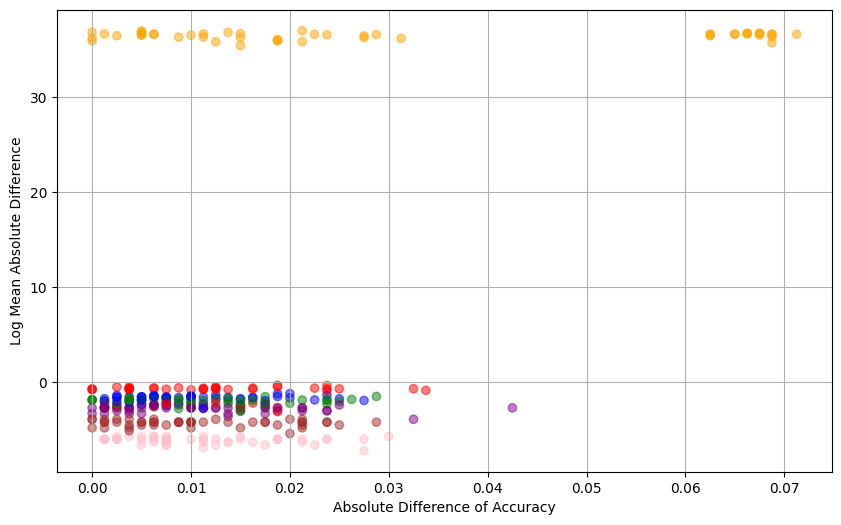

In [36]:
# plot the result
# x axis is the absoulte value of the difference of accuracy
# y axis is the log of the mean_abs_difference
import matplotlib.pyplot as plt
import numpy as np

df_target['abs_acc_diff'] = df_target['accuracy_change'].abs()
df_target['log_mean_abs_difference'] = df_target['mean_abs_difference'].apply(lambda x: np.log10(x) if x > 0 else pd.np.nan)

abs_acc_change_mean = df_target[df_target['accuracy_change'].notna()]['accuracy_change'].abs().mean()

#color by the bit_index
df_target['bit_index'] = df_target['bit_index'].astype(str)

plt.figure(figsize=(10, 6))
#plt.scatter(df_target['abs_acc_diff'], df_target['log_mean_abs_difference'], alpha=0.5)
# add folder_of_interest, prior_b, activation_fn, prior, param_type to the title
#plt.title(f'Absolute Mean in Accuracy vs Log Mean Absolute Difference\nShipsNet SEU Analysis: {folder_of_interest} | Prior b: {prior_b_filter} | \nActivation Function: {activation_fn_filter} | Prior: {prior_filter} | Param Type: {param_type_filter}\n Mean Accuracy Difference: {abs_acc_change_mean:.4f}')
#plt.title('Absolute Mean in Accuracy vs Log Mean Absolute Difference')
plt.xlabel('Absolute Difference of Accuracy')
plt.ylabel('Log Mean Absolute Difference')
#plt.yscale('log')

# create a dictionary to map bit_index to colors
colors = {'0': 'blue', 
          '1': 'orange', 
          '3': 'green', 
          '6': 'red', 
          '10': 'purple', 
          '15': 'brown', 
          '21': 'pink', 
          '30': 'gray'}

plt.scatter(df_target['abs_acc_diff'], 
            df_target['log_mean_abs_difference'],
            c=df_target['bit_index'].map(colors),
            alpha=0.5, label=df_target['bit_index'])

#show legend
#plt.colorbar(label='Bit Index')
plt.grid(True)
plt.show()

In [37]:
stopdeh

NameError: name 'stopdeh' is not defined

In [ ]:
df_target

In [ ]:
df_target = df_master[(df_master['prior_b'] == 1.0) & 
                      (df_master['activation_fn'] == 'relu') &
                      #(df_master['bit_index'] == 1) &
                      (df_master['prior'] == 'gaussian') &
                      (df_master['param_type'] == 'scales')].reset_index(drop=True)

#df_target = df_target[df_target['activation_fn'] == 'relu'].reset_index(drop=True)
#df_target = df_target[df_target['bit_index'] == 1].reset_index(drop=True)
#df_target = df_target[df_target['prior'] == 'gaussian'].reset_index(drop=True)
df_target

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

df_target['abs_acc_diff'] = df_target['accuracy_change'].abs()
df_target['log_mean_abs_difference'] = df_target['mean_abs_difference'].apply(lambda x: np.log10(x) if x > 0 else pd.np.nan)

#color by the bit_index
df_target['bit_index'] = df_target['bit_index'].astype(str)

plt.figure(figsize=(10, 6))
#plt.scatter(df_target['abs_acc_diff'], df_target['log_mean_abs_difference'], alpha=0.5)
plt.title('Softmax Difference vs Log Mean Absolute Difference')
plt.xlabel('Absolute Difference of Accuracy')
plt.ylabel('Log Mean Absolute Difference')
#plt.yscale('log')

# create a dictionary to map bit_index to colors
colors = {'0': 'blue', 
          '1': 'orange', 
          '3': 'green', 
          '6': 'red', 
          '10': 'purple', 
          '15': 'brown', 
          '21': 'pink', 
          '30': 'gray'}

plt.scatter(df_target['abs_acc_diff'], 
            df_target['log_mean_abs_difference'],
            c=df_target['bit_index'].map(colors),
            alpha=0.5, label=df_target['bit_index'])

#show legend
#plt.colorbar(label='Bit Index')
plt.grid(True)
plt.show()

In [ ]:
def plot_seu_result():
    """
    input : what variables to show, what parameters to filter
    output : show graph
    """

    # plot the graph

    pass